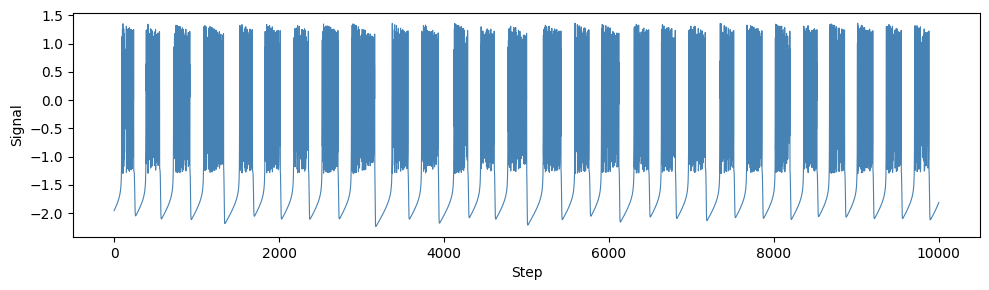

Compiling Numba kernels (first call only)...
Compilation done in 0.9s
Full grid size                : 21168
Random-sampled trial budget   : 800
Tier 1 density                : tau_filt=6, SR=7, reg=7
[10/800]  elapsed: 7s  ETA: 582s  current best NRMSE: 1.441938
[20/800]  elapsed: 16s  ETA: 606s  current best NRMSE: 1.441938
[30/800]  elapsed: 22s  ETA: 577s  current best NRMSE: 1.369202
[40/800]  elapsed: 29s  ETA: 558s  current best NRMSE: 1.345751
[50/800]  elapsed: 38s  ETA: 565s  current best NRMSE: 1.345751
[60/800]  elapsed: 45s  ETA: 556s  current best NRMSE: 1.345751
[70/800]  elapsed: 53s  ETA: 554s  current best NRMSE: 1.345751
[80/800]  elapsed: 60s  ETA: 537s  current best NRMSE: 1.345751
[90/800]  elapsed: 67s  ETA: 529s  current best NRMSE: 1.345751
[100/800]  elapsed: 75s  ETA: 526s  current best NRMSE: 1.345751
[110/800]  elapsed: 84s  ETA: 525s  current best NRMSE: 1.345751
[120/800]  elapsed: 94s  ETA: 535s  current best NRMSE: 1.345751
[130/800]  elapsed: 103s  ETA:

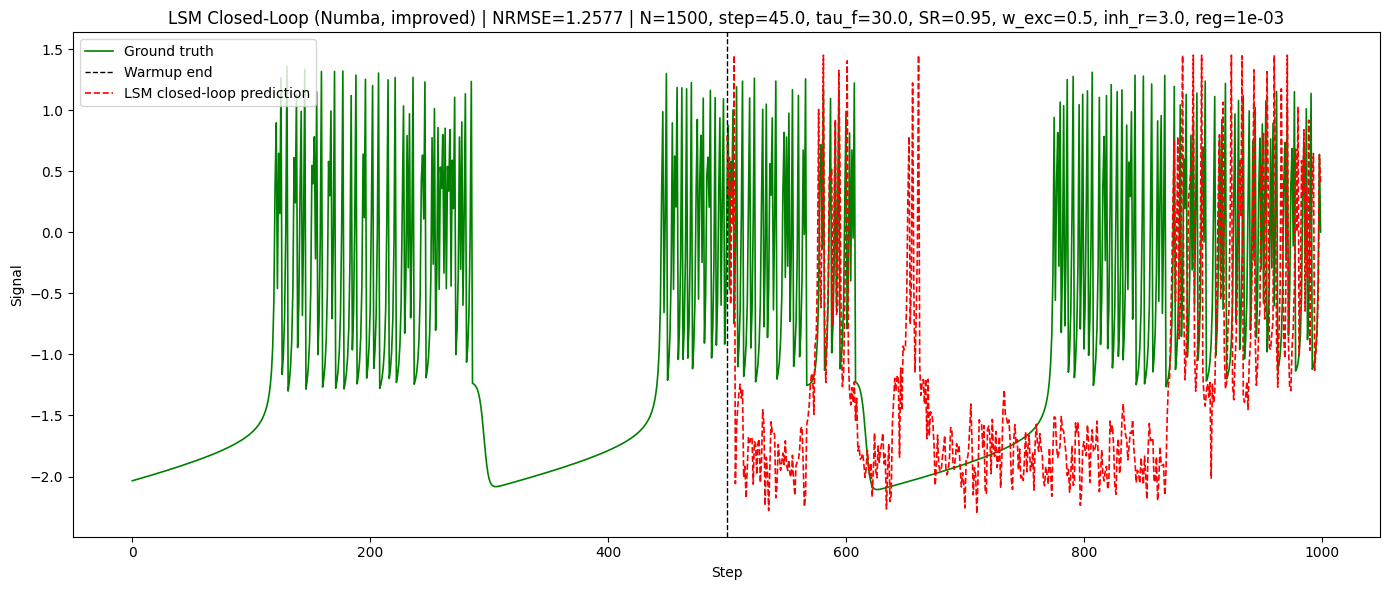

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
from numba import njit
from sklearn.linear_model import Ridge, Lasso

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..',)))
from lib.utils.reservoirpy import (
    fit_scaler, transform_array, inverse_transform_array
)

np.random.seed(42)


# ==========================================================
# LOAD DATA
# ==========================================================
dataset = np.loadtxt('../../../data/chaotic_data/rulkov_map.csv', delimiter=',')
dataset = dataset[:, 0]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset, color='steelblue', linewidth=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Signal')
plt.tight_layout(); plt.show()


# ==========================================================
# DATA PREPARATION
# ==========================================================
data = dataset.reshape(-1, 1)
X_raw = data[:-1]
Y_raw = data[1:]


# ==========================================================
# FIXED SETTINGS
# ==========================================================
train_len        = 4000
test_start       = 4000
test_len         = 1000
regression_model = "ridge"
seed             = 42

# Readout feature mode: "linear" (state only) or "quadratic" ([state, state**2])
READOUT_FEATURES = "quadratic"

# Training noise amplitude injected into reservoir states before Ridge fit.
# Small noise here regularizes the readout and improves closed-loop robustness.
TRAIN_NOISE_STD  = 1e-4

X_train_raw = X_raw[:train_len]
Y_train_raw = Y_raw[:train_len]
X_test_raw  = X_raw[test_start:test_start + test_len]
Y_test_raw  = Y_raw[test_start:test_start + test_len]


# ==========================================================
# NUMBA-ACCELERATED LIF KERNELS
# ==========================================================

@njit(cache=True)
def _encode_population(x_scalar, mu, sigma_enc):
    """Gaussian population encoding: scalar -> (N_input,) activation vector."""
    N = mu.shape[0]
    out = np.empty(N)
    inv_2s2 = 1.0 / (2.0 * sigma_enc * sigma_enc)
    for i in range(N):
        diff = mu[i] - x_scalar
        out[i] = np.exp(-diff * diff * inv_2s2)
    return out


@njit(cache=True)
def _encode_direct(x_scalar, N_input):
    out = np.empty(N_input)
    for i in range(N_input):
        out[i] = x_scalar
    return out


@njit(cache=True)
def _simulate_one_sample(
    V, I_syn, refrac,
    W_rec, I_input,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn,
    refrac_steps,
):
    """
    Advance the LIF reservoir by n_substeps integration steps.
    Modifies V, I_syn, refrac in-place.
    Returns spike counts per neuron during this window.
    """
    N = V.shape[0]
    spike_counts = np.zeros(N)

    for step in range(n_substeps):
        # Voltage update
        for i in range(N):
            if refrac[i] <= 0:
                V[i] = (
                    V_rest
                    + (V[i] - V_rest) * decay_mem
                    + (I_syn[i] + I_input[i]) * drive_scale
                )
            else:
                refrac[i] -= 1

        # Decay synaptic currents
        for i in range(N):
            I_syn[i] *= decay_syn

        # Spike detection + delivery
        for i in range(N):
            if V[i] >= V_thresh:
                spike_counts[i] += 1.0
                V[i] = V_reset
                refrac[i] = refrac_steps
                for post in range(N):
                    I_syn[post] += W_rec[post, i]

    return spike_counts


@njit(cache=True)
def _run_sequence(
    input_sequence,
    V, I_syn, refrac, filt,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn, decay_filt,
    refrac_steps,
    use_population,
):
    T = input_sequence.shape[0]
    N = V.shape[0]
    N_input = mu.shape[0]
    states = np.zeros((T, N))

    for t in range(T):
        x = input_sequence[t, 0]

        if use_population:
            inp_act = _encode_population(x, mu, sigma_enc)
        else:
            inp_act = _encode_direct(x, N_input)

        I_input = np.zeros(N)
        for post in range(N):
            for j in range(N_input):
                I_input[post] += W_in[post, j] * inp_act[j]

        counts = _simulate_one_sample(
            V, I_syn, refrac,
            W_rec, I_input,
            n_substeps,
            V_rest, V_reset, V_thresh,
            decay_mem, drive_scale, decay_syn,
            refrac_steps,
        )

        # Exponential filter (decay_filt now uses tau_filt, not tau_syn)
        for i in range(N):
            filt[i] = filt[i] * decay_filt + counts[i]
            states[t, i] = filt[i]

    return states


@njit(cache=True)
def _run_one_step(
    x_scalar,
    V, I_syn, refrac, filt,
    W_rec, W_in, mu, sigma_enc,
    n_substeps,
    V_rest, V_reset, V_thresh,
    decay_mem, drive_scale, decay_syn, decay_filt,
    refrac_steps,
    use_population,
):
    N = V.shape[0]
    N_input = mu.shape[0]

    if use_population:
        inp_act = _encode_population(x_scalar, mu, sigma_enc)
    else:
        inp_act = _encode_direct(x_scalar, N_input)

    I_input = np.zeros(N)
    for post in range(N):
        for j in range(N_input):
            I_input[post] += W_in[post, j] * inp_act[j]

    counts = _simulate_one_sample(
        V, I_syn, refrac,
        W_rec, I_input,
        n_substeps,
        V_rest, V_reset, V_thresh,
        decay_mem, drive_scale, decay_syn,
        refrac_steps,
    )

    for i in range(N):
        filt[i] = filt[i] * decay_filt + counts[i]

    return filt.copy()


# ==========================================================
# WRAPPER CLASS
# ==========================================================
class LIFReservoir:
    """
    LIF reservoir with:
      - separate tau_filt (decoupled from tau_syn) -> proper readout memory
      - target spectral radius rescaling of W_rec  -> controlled edge-of-chaos
      - inhibitory weights passed as MAGNITUDE (sign applied internally)
    """

    def __init__(
        self,
        N_liquid, N_input=50,
        tau_mem=30.0, tau_syn=5.0, tau_filt=50.0,
        dt=1.0, step_duration=25.0,
        V_rest=-65.0, V_reset=-65.0, V_thresh=-50.0,
        refrac_steps=2, exc_frac=0.8,
        conn_prob=0.1, input_conn_prob=0.3,
        w_exc=0.5, w_inh_mag=2.0, w_input=1.0,
        spectral_radius=None,       # if set, rescale W_rec to this SR
        encoding="population", sigma_enc=0.2,
        rng_seed=42,
    ):
        self.N          = N_liquid
        self.N_input    = N_input
        self.n_substeps = int(round(step_duration / dt))
        self.V_rest     = V_rest
        self.V_reset    = V_reset
        self.V_thresh   = V_thresh
        self.refrac_steps = refrac_steps
        self.use_population = (encoding == "population")

        # Precompute decays.
        #
        # tau_mem -> membrane leak within substeps
        # tau_syn -> synaptic current decay within substeps
        # tau_filt -> OUTPUT filter decay BETWEEN samples (across step_duration)
        #
        # Previously decay_filt used tau_syn, which at step=25, tau_syn=5 gave
        # decay_filt ~ 0.007 (no cross-sample memory). This now uses tau_filt.
        self.decay_mem   = np.exp(-dt / tau_mem)
        self.drive_scale = 1.0 - self.decay_mem
        self.decay_syn   = np.exp(-dt / tau_syn)
        self.decay_filt  = np.exp(-step_duration / tau_filt)

        # Encoder
        self.mu        = np.linspace(-1.0, 1.0, N_input)
        self.sigma_enc = sigma_enc

        # ---- Build weight matrices ----
        rng = np.random.RandomState(rng_seed)
        n_exc = int(exc_frac * N_liquid)

        # Recurrent W_rec[post, pre]: excitatory columns carry +w_exc,
        # inhibitory columns carry -w_inh_mag. w_inh_mag is a positive
        # magnitude; the sign is applied here so the caller cannot accidentally
        # pass the wrong sign.
        W_rec = np.zeros((N_liquid, N_liquid), dtype=np.float64)
        mask  = rng.rand(N_liquid, N_liquid) < conn_prob
        np.fill_diagonal(mask, False)
        W_rec[mask] = w_exc  # default everyone to excitatory...
        inh_cols = np.arange(n_exc, N_liquid)  # ...then overwrite inhibitory cols
        for col in inh_cols:
            for row in range(N_liquid):
                if mask[row, col]:
                    W_rec[row, col] = -w_inh_mag

        # Rescale to target spectral radius (once, outside Numba path).
        # This is the standard ESN practice for reservoir stability.
        if spectral_radius is not None:
            # Use full eigvals for moderate N; for very large N switch to eigs.
            try:
                eigvals = np.linalg.eigvals(W_rec)
                current_sr = np.max(np.abs(eigvals))
                if current_sr > 1e-12:
                    W_rec *= (spectral_radius / current_sr)
            except np.linalg.LinAlgError:
                pass

        self.W_rec = W_rec

        # Input weights
        W_in_mask = rng.rand(N_liquid, N_input) < input_conn_prob
        self.W_in = np.where(W_in_mask, w_input, 0.0).astype(np.float64)

        self.reset_state()

    def reset_state(self):
        self.V      = np.full(self.N, self.V_rest)
        self.I_syn  = np.zeros(self.N)
        self.refrac = np.zeros(self.N, dtype=np.int32)
        self.filt   = np.zeros(self.N)

    def run_sequence(self, input_sequence):
        return _run_sequence(
            np.ascontiguousarray(input_sequence),
            self.V, self.I_syn, self.refrac, self.filt,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            self.V_rest, self.V_reset, self.V_thresh,
            self.decay_mem, self.drive_scale, self.decay_syn, self.decay_filt,
            self.refrac_steps, self.use_population,
        )

    def run_one_step(self, x_scalar):
        return _run_one_step(
            float(x_scalar),
            self.V, self.I_syn, self.refrac, self.filt,
            self.W_rec, self.W_in, self.mu, self.sigma_enc,
            self.n_substeps,
            self.V_rest, self.V_reset, self.V_thresh,
            self.decay_mem, self.drive_scale, self.decay_syn, self.decay_filt,
            self.refrac_steps, self.use_population,
        )


# ==========================================================
# READOUT FEATURE HELPERS
# ==========================================================
def make_features(S, mode):
    """Expand state matrix into readout features."""
    if mode == "linear":
        return S
    elif mode == "quadratic":
        return np.hstack([S, S ** 2])
    else:
        raise ValueError(f"unknown readout feature mode: {mode}")


# ==========================================================
# WARM UP NUMBA
# ==========================================================
print("Compiling Numba kernels (first call only)...")
t_compile = time.time()
_dummy = LIFReservoir(N_liquid=50, N_input=10, step_duration=10.0, spectral_radius=0.9)
_ = _dummy.run_sequence(np.zeros((10, 1)))
_ = _dummy.run_one_step(0.0)
print(f"Compilation done in {time.time() - t_compile:.1f}s")


# ==========================================================
# PARAMETER GRID  (budget-focused: dense on Tier 1, coarse elsewhere)
# ==========================================================
#
# Sensitivity tiers for closed-loop Rulkov prediction:
#
# Tier 1 (dominant)     : tau_filt, spectral_radius, regression
# Tier 2 (strong)       : N_liquid, step_duration, w_input
# Tier 3 (modest)       : tau_mem, inh_ratio
# Tier 4 (fixed)        : tau_syn, w_exc, encoding, warmups
#
# Why some things are fixed:
#  - w_exc : spectral_radius rescaling normalizes W_rec, making absolute
#            w_exc nearly meaningless. Fix at 0.5.
#  - tau_syn: 5-9ms is the stable band; sweeping it just wastes budget. Fix at 7.
#
# Full combinatorial size is intentionally larger than budget, and we
# random-subsample. Random subsampling of a carefully-designed grid typically
# outperforms full grid on a poorly-designed one.

param_grid = {
    "normalization":     ["minmax11"],
    "train_warmup":      [500],
    "test_warmup":       [500],

    # --- Tier 4 (fixed) ---
    "tau_syn":           [7.0],
    "w_exc":             [0.5],
    "encoding":          ["population"],

    # --- Tier 3 (coarse) ---
    "tau_mem":           [40.0, 80.0],
    "inh_ratio":         [3.0, 5.0],

    # --- Tier 2 (moderate) ---
    "N_liquid":          [800, 1500],
    "step_duration":     [20.0, 30.0, 45.0],
    "w_input":           [0.8, 1.5, 2.5],

    # --- Tier 1 (dense, this is where it matters) ---
    # tau_filt: log-spaced, covers fast-synapse to burst-envelope scales.
    # The Rulkov burst envelope in typical (beta=4.1) data has periods ~100
    # samples; tau_filt should span from shorter than this to longer.
    "tau_filt":          [30.0, 60.0, 100.0, 150.0, 250.0, 400.0],

    # spectral_radius: dense near 1, which is where chaotic tasks usually live
    "spectral_radius":   [0.85, 0.95, 1.05, 1.15, 1.25, 1.3, 1.5],

    # regression: Ridge alpha, log-spaced across 6 orders of magnitude
    "regression":        [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
}

keys       = list(param_grid.keys())
all_combos = list(itertools.product(*[param_grid[k] for k in keys]))

# Random-subsample to a target budget.
# At ~2 s/trial, 800 trials ~= 25-30 min.
N_TRIALS  = min(800, len(all_combos))
rng_sampler = np.random.RandomState(seed)
idx       = rng_sampler.choice(len(all_combos), size=N_TRIALS, replace=False)
combos    = [all_combos[i] for i in idx]

print(f"Full grid size                : {len(all_combos)}")
print(f"Random-sampled trial budget   : {len(combos)}")
print(f"Tier 1 density                : "
      f"tau_filt={len(param_grid['tau_filt'])}, "
      f"SR={len(param_grid['spectral_radius'])}, "
      f"reg={len(param_grid['regression'])}")


# ==========================================================
# EVALUATION
# ==========================================================
def evaluate_lsm(
    normalization, train_warmup, test_warmup,
    N_liquid, step_duration, tau_mem, tau_syn, tau_filt,
    spectral_radius,
    w_exc, inh_ratio, w_input, regression, encoding,
    rng_seed=42,
):
    try:
        if test_warmup >= test_len:
            return np.inf

        scaler  = fit_scaler(X_train_raw, method=normalization)
        X_train = transform_array(X_train_raw, scaler)
        Y_train = transform_array(Y_train_raw, scaler)
        X_test  = transform_array(X_test_raw,  scaler)
        Y_test  = transform_array(Y_test_raw,  scaler)

        # ---- closed-loop clipping bounds, inferred from training data ----
        x_lo = float(X_train.min()) - 0.05
        x_hi = float(X_train.max()) + 0.05

        pred_len      = test_len - test_warmup
        Y_true_scaled = Y_test[test_warmup:test_warmup + pred_len, 0]

        if train_warmup >= len(X_train):
            return np.inf

        lsm = LIFReservoir(
            N_liquid=N_liquid, N_input=50,
            tau_mem=tau_mem, tau_syn=tau_syn, tau_filt=tau_filt,
            dt=1.0, step_duration=step_duration,
            w_exc=w_exc, w_inh_mag=inh_ratio * w_exc, w_input=w_input,
            spectral_radius=spectral_radius,
            encoding=encoding, rng_seed=rng_seed,
        )

        # Training pass
        S_train = lsm.run_sequence(X_train)

        mean_rate = S_train.mean()
        if mean_rate < 1e-3 or mean_rate > 1e4 or not np.isfinite(mean_rate):
            return np.inf

        S_train_fit = S_train[train_warmup:]
        Y_train_fit = Y_train[train_warmup:, 0]

        # Inject small training noise before feature expansion.
        # This regularizes the readout for closed-loop robustness.
        if TRAIN_NOISE_STD > 0:
            noise_rng = np.random.RandomState(rng_seed + 1)
            S_train_fit = S_train_fit + noise_rng.normal(
                0.0, TRAIN_NOISE_STD, size=S_train_fit.shape
            )

        # Feature expansion: linear or quadratic
        F_train_fit = make_features(S_train_fit, READOUT_FEATURES)

        if regression_model == "ridge":
            readout = Ridge(alpha=regression)
        else:
            readout = Lasso(alpha=regression, max_iter=10000)
        readout.fit(F_train_fit, Y_train_fit)

        # Sync on test warmup
        lsm.reset_state()
        lsm.run_sequence(X_test[:test_warmup])

        # Closed-loop rollout with clipping to training range.
        # Clipping prevents catastrophic divergence when predictions escape
        # the range covered by the population encoder.
        Y_pred_scaled = np.zeros(pred_len)
        current_input = float(X_test[test_warmup, 0])

        for k in range(pred_len):
            state = lsm.run_one_step(current_input)
            feat  = make_features(state.reshape(1, -1), READOUT_FEATURES)
            pred  = readout.predict(feat)[0]
            if not np.isfinite(pred) or abs(pred) > 1e6:
                return np.inf
            # clip to keep input inside the encoder's covered range
            pred = float(np.clip(pred, x_lo, x_hi))
            Y_pred_scaled[k] = pred
            current_input = pred

        rmse  = np.sqrt(np.mean((Y_true_scaled - Y_pred_scaled) ** 2))
        denom = np.std(Y_true_scaled)
        if denom == 0:
            return np.inf
        return rmse / denom

    except Exception as e:
        print(f"    ERROR: {e}")
        return np.inf


# ==========================================================
# RUN GRID SEARCH
# ==========================================================
results     = []
best_nrmse  = np.inf
best_params = None
t_start     = time.time()

for trial_idx, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    nrmse  = evaluate_lsm(**params, rng_seed=seed)
    results.append({**params, "nrmse": nrmse})

    if nrmse < best_nrmse:
        best_nrmse  = nrmse
        best_params = params.copy()

    if (trial_idx + 1) % 10 == 0 or (trial_idx + 1) == len(combos):
        elapsed = time.time() - t_start
        eta     = elapsed / (trial_idx + 1) * (len(combos) - (trial_idx + 1))
        print(
            f"[{trial_idx+1}/{len(combos)}]  "
            f"elapsed: {elapsed:.0f}s  ETA: {eta:.0f}s  "
            f"current best NRMSE: {best_nrmse:.6f}"
        )

total_time = time.time() - t_start


# ==========================================================
# RESULTS
# ==========================================================
print("\n" + "=" * 80)
print("LSM RANDOM SEARCH COMPLETE (Numba LIF, improved)")
print(f"Train interval      : [0 : {train_len}]")
print(f"Test interval       : [{test_start} : {test_start + test_len}]")
print(f"Total time          : {total_time:.1f}s ({total_time/len(combos):.2f}s/trial)")
print(f"Readout             : {regression_model}  ({READOUT_FEATURES} features)")
print(f"Training noise std  : {TRAIN_NOISE_STD}")
print(f"Best NRMSE          : {best_nrmse:.6f}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k:22s} = {v}")
print("=" * 80)

results_sorted = sorted(results, key=lambda r: r["nrmse"])

print("\nTop 10 configurations:")
header = (
    f"{'Rank':>4}  {'N':>5}  {'step':>5}  {'tau_m':>5}  {'tau_f':>5}  "
    f"{'SR':>5}  {'w_exc':>6}  {'inh_r':>5}  {'w_in':>5}  {'reg':>8}  "
    f"{'NRMSE':>10}"
)
print(header)
print("-" * len(header))
for rank, r in enumerate(results_sorted[:10], 1):
    print(
        f"{rank:4d}  "
        f"{int(r['N_liquid']):5d}  "
        f"{r['step_duration']:5.1f}  "
        f"{r['tau_mem']:5.1f}  "
        f"{r['tau_filt']:5.1f}  "
        f"{r['spectral_radius']:5.2f}  "
        f"{r['w_exc']:6.2f}  "
        f"{r['inh_ratio']:5.1f}  "
        f"{r['w_input']:5.2f}  "
        f"{r['regression']:8.1e}  "
        f"{r['nrmse']:10.6f}"
    )


# ==========================================================
# REBUILD BEST MODEL & PLOT
# ==========================================================
bp = best_params
best_scaler = fit_scaler(X_train_raw, method=bp["normalization"])
X_train_b   = transform_array(X_train_raw, best_scaler)
Y_train_b   = transform_array(Y_train_raw, best_scaler)
X_test_b    = transform_array(X_test_raw,  best_scaler)
Y_test_b    = transform_array(Y_test_raw,  best_scaler)

x_lo = float(X_train_b.min()) - 0.05
x_hi = float(X_train_b.max()) + 0.05

lsm = LIFReservoir(
    N_liquid=bp["N_liquid"], N_input=50,
    tau_mem=bp["tau_mem"], tau_syn=bp["tau_syn"], tau_filt=bp["tau_filt"],
    dt=1.0, step_duration=bp["step_duration"],
    w_exc=bp["w_exc"], w_inh_mag=bp["inh_ratio"] * bp["w_exc"],
    w_input=bp["w_input"],
    spectral_radius=bp["spectral_radius"],
    encoding=bp["encoding"], rng_seed=seed,
)

S_train = lsm.run_sequence(X_train_b)
S_fit   = S_train[bp["train_warmup"]:]
Y_fit   = Y_train_b[bp["train_warmup"]:, 0]

if TRAIN_NOISE_STD > 0:
    noise_rng = np.random.RandomState(seed + 1)
    S_fit = S_fit + noise_rng.normal(0.0, TRAIN_NOISE_STD, size=S_fit.shape)

F_fit = make_features(S_fit, READOUT_FEATURES)

if regression_model == "ridge":
    readout = Ridge(alpha=bp["regression"])
else:
    readout = Lasso(alpha=bp["regression"], max_iter=10000)
readout.fit(F_fit, Y_fit)

lsm.reset_state()
lsm.run_sequence(X_test_b[:bp["test_warmup"]])

pred_len = test_len - bp["test_warmup"]
Y_pred_scaled = np.zeros(pred_len)
current_input = float(X_test_b[bp["test_warmup"], 0])

for k in range(pred_len):
    state = lsm.run_one_step(current_input)
    feat  = make_features(state.reshape(1, -1), READOUT_FEATURES)
    pred  = readout.predict(feat)[0]
    pred  = float(np.clip(pred, x_lo, x_hi))
    Y_pred_scaled[k] = pred
    current_input = pred

Y_pred_b = inverse_transform_array(
    Y_pred_scaled.reshape(-1, 1), best_scaler
).ravel()
Y_true_b = inverse_transform_array(
    Y_test_b[bp["test_warmup"]:bp["test_warmup"] + pred_len], best_scaler
).ravel()

mse   = np.mean((Y_true_b - Y_pred_b) ** 2)
rmse  = np.sqrt(mse)
nrmse = rmse / np.std(Y_true_b)

print(f"\nFinal best-model metrics (original scale):")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")
print(f"Avg filtered state (training): {S_train.mean():.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test_raw[:, 0], c="green",
        label="Ground truth", linewidth=1.2)
ax.axvline(bp["test_warmup"], ls="--", c="k", lw=1.0, label="Warmup end")
ax.plot(np.arange(bp["test_warmup"], bp["test_warmup"] + pred_len),
        Y_pred_b, ls="--", c="red", label="LSM closed-loop prediction", lw=1.2)
ax.set_title(
    f"LSM Closed-Loop (Numba, improved) | NRMSE={nrmse:.4f} | "
    f"N={bp['N_liquid']}, step={bp['step_duration']}, "
    f"tau_f={bp['tau_filt']}, SR={bp['spectral_radius']}, "
    f"w_exc={bp['w_exc']}, inh_r={bp['inh_ratio']}, reg={bp['regression']:.0e}"
)
ax.set_xlabel("Step"); ax.set_ylabel("Signal")
ax.legend(); plt.tight_layout(); plt.show()